# Assignment 5 — Clustering and Initialization
### k-means (random init) vs. k-means++ init — Lloyd's algorithm from scratch

**Stage 1 of 3**: algorithm implementation + correctness checks.
Datasets, experiments (30 trials/method/dataset), and plots come in Stage 2.
Report, README, and reproducibility instructions come in Stage 3.

Run every cell top to bottom from a fresh kernel.

## 0. Setup

In [2]:
import numpy as np
from pathlib import Path

# Create output folders used in later stages (safe to run now)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=4, suppress=True)
print("NumPy version:", np.__version__)

NumPy version: 2.5.2


## 1. Input validation

Two validation functions: one for the data/`k` (used by every function), and one
for the Lloyd-loop parameters `max_iter`/`tol`. Both explicitly reject Python/NumPy
booleans for integer arguments, since `bool` is a subclass of `int` in Python and
would otherwise silently pass through as `0`/`1`.

In [3]:
def _validate_kmeans_inputs(X, k):
    """Checks shared by all functions: shape, feature count, k validity, finiteness."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"X must be a 2D array, got shape {X.shape}")
    n, d = X.shape
    if n == 0:
        raise ValueError("X has zero samples")
    if d == 0:
        raise ValueError("X must have at least one feature (d >= 1)")
    if isinstance(k, (bool, np.bool_)) or not isinstance(k, (int, np.integer)) or k < 1:
        raise ValueError(f"k must be a positive integer, got {k!r}")
    if k > n:
        raise ValueError(f"k={k} cannot exceed the number of samples n={n}")
    if not np.all(np.isfinite(X)):
        raise ValueError("X contains NaN or infinite values")
    return X, n, d


def _validate_lloyd_params(max_iter, tol):
    """Checks for the Lloyd-loop parameters."""
    if isinstance(max_iter, (bool, np.bool_)) or not isinstance(max_iter, (int, np.integer)) or max_iter < 1:
        raise ValueError(f"max_iter must be a positive integer, got {max_iter!r}")
    if not isinstance(tol, (int, float, np.integer, np.floating)) or not np.isfinite(tol) or tol < 0:
        raise ValueError(f"tol must be a finite nonnegative number, got {tol!r}")
    return int(max_iter), float(tol)

## 2. Initialization methods

- **Random**: draw `k` distinct row indices uniformly without replacement.
- **k-means++**: pick the first center uniformly; each subsequent center is sampled
  with probability proportional to its squared distance to the nearest already-chosen
  center. If every remaining point has zero distance to a chosen center (e.g. all
  remaining points are duplicates of existing centers), the proportional-sampling
  probabilities are undefined (0/0), so we fall back to uniform sampling for that step.

In [4]:
def init_random(X, k, rng):
    X, n, d = _validate_kmeans_inputs(X, k)
    idx = rng.choice(n, size=k, replace=False)
    return X[idx].copy()

In [5]:
def init_kmeans_pp(X, k, rng):
    X, n, d = _validate_kmeans_inputs(X, k)
    centers = np.empty((k, d))

    first_idx = rng.integers(n)
    centers[0] = X[first_idx]
    closest_sq_dist = np.sum((X - centers[0]) ** 2, axis=1)

    for i in range(1, k):
        total = closest_sq_dist.sum()
        if total <= 0:
            # Zero-total-distance case: all remaining points coincide with an
            # already-chosen center. Proportional sampling is undefined, so we
            # fall back to uniform sampling over all points.
            next_idx = rng.integers(n)
        else:
            probs = closest_sq_dist / total
            next_idx = rng.choice(n, p=probs)
        centers[i] = X[next_idx]
        new_sq_dist = np.sum((X - centers[i]) ** 2, axis=1)
        closest_sq_dist = np.minimum(closest_sq_dist, new_sq_dist)

    return centers

## 3. Assignment step and inertia

In [6]:
def assign_clusters(X, centers):
    """Nearest-center assignment. Returns labels (n,) and squared distances (n, k)."""
    dist_sq = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    labels = np.argmin(dist_sq, axis=1)
    return labels, dist_sq


def compute_inertia(X, centers, labels):
    """Sum of squared distances of each point to its assigned center."""
    diffs = X - centers[labels]
    return float(np.sum(diffs ** 2))

## 4. Update step (with empty-cluster handling)

**Empty clusters.** If a cluster receives no points, its mean is undefined. We
handle this by reassigning that cluster's center to the point that is currently
**farthest from its own assigned center** (an outlier under the current
partition). This breaks up the cluster that is contributing the most inertia and
gives the empty cluster a sensible new location, and it cannot increase inertia
on the following assignment step. If several clusters are empty at once, each
gets the next-farthest available point so no point is reused.

In [7]:
def update_centers(X, labels, k, dist_to_own_center, rng):
    n, d = X.shape
    centers = np.empty((k, d))
    counts = np.bincount(labels, minlength=k)

    for j in range(k):
        if counts[j] > 0:
            centers[j] = X[labels == j].mean(axis=0)

    empty_clusters = np.where(counts == 0)[0]
    if len(empty_clusters) > 0:
        order = np.argsort(-dist_to_own_center)  # farthest-from-own-center first
        available = np.ones(n, dtype=bool)
        oi = 0
        for j in empty_clusters:
            while not available[order[oi]]:
                oi += 1
            pt_idx = order[oi]
            centers[j] = X[pt_idx]
            available[pt_idx] = False
            oi += 1

    return centers

## 5. Lloyd's algorithm

**Stopping rule (documented, fixed).** After each update+assignment we compute
`change = inertia_prev - inertia_new` (positive = improvement) and a scale-aware
numerical tolerance `eps = 1e-8 * max(|inertia_prev|, |inertia_new|, 1.0)`.

- If `change < -eps`, inertia genuinely increased beyond floating-point noise —
  this violates Lloyd's non-increasing guarantee, so we raise a `RuntimeError`
  instead of ever calling it convergence.
- Otherwise we stop once the *relative* improvement
  `change / max(inertia_prev, 1e-12)` is `<= tol` (note `<=`, not `<`): with
  `tol=0` this correctly recognizes an exactly unchanged solution as converged,
  instead of running to `max_iter`.
- We stop after at most `max_iter` iterations, with `converged=False` if the
  threshold was never reached.

**Bug that was fixed:** the previous version compared with `<`. A genuine
inertia increase gives a *negative* `change`, so `rel_change < tol` was true
for any positive `tol` — an increase was silently reported as convergence.
The explicit increase check above (run before the tol comparison) fixes this
and is a standalone function so it can be tested directly.

In [8]:
def _check_inertia_non_increasing(old_inertia, new_inertia, iteration):
    """Raise if inertia increased beyond a scale-aware numerical tolerance.

    Kept as a standalone function so the detection logic can be unit-tested
    directly, without needing to engineer a run that actually misbehaves.
    """
    eps = 1e-8 * max(abs(old_inertia), abs(new_inertia), 1.0)
    if old_inertia - new_inertia < -eps:
        raise RuntimeError(
            f"Inertia increased at iteration {iteration}: "
            f"{old_inertia:.10g} -> {new_inertia:.10g} (beyond tolerance {eps:.3g}). "
            "This indicates a bug in the update/assignment step, not convergence."
        )


def lloyd_kmeans(X, k, init="random", rng=None, max_iter=300, tol=1e-4):
    """K-means via Lloyd's algorithm.

    Parameters
    ----------
    X : array-like, shape (n, d), d >= 1
    k : positive int, k <= n
    init : {"random", "kmeans++"}
    rng : numpy.random.Generator (use np.random.default_rng(seed))
    max_iter : positive int
    tol : finite, nonnegative float; relative-inertia-decrease stopping threshold

    Returns
    -------
    dict with keys: centers, labels, inertia, inertia_history, n_iter, converged
    """
    if rng is None:
        rng = np.random.default_rng()
    X, n, d = _validate_kmeans_inputs(X, k)
    max_iter, tol = _validate_lloyd_params(max_iter, tol)

    if init == "random":
        centers = init_random(X, k, rng)
    elif init == "kmeans++":
        centers = init_kmeans_pp(X, k, rng)
    else:
        raise ValueError(f"Unknown init method: {init!r}. Use 'random' or 'kmeans++'.")

    labels, dist_sq = assign_clusters(X, centers)
    dist_to_own = dist_sq[np.arange(n), labels]
    inertia = float(dist_to_own.sum())
    inertia_history = [inertia]

    converged = False
    n_iter = 0
    for iteration in range(1, max_iter + 1):
        n_iter = iteration
        centers = update_centers(X, labels, k, dist_to_own, rng)
        labels, dist_sq = assign_clusters(X, centers)
        dist_to_own = dist_sq[np.arange(n), labels]
        new_inertia = float(dist_to_own.sum())
        inertia_history.append(new_inertia)

        _check_inertia_non_increasing(inertia, new_inertia, iteration)

        change = inertia - new_inertia  # >= -eps, guaranteed by the check above
        rel_change = change / max(inertia, 1e-12)
        inertia = new_inertia
        if rel_change <= tol:
            converged = True
            break

    return {
        "centers": centers,
        "labels": labels,
        "inertia": inertia,
        "inertia_history": np.array(inertia_history),
        "n_iter": n_iter,
        "converged": converged,
    }

## 6. Correctness checks

Assertion-based checks, now including regression tests for: parameter
validation (invalid `k`, `max_iter`, `tol`, zero-feature `X`), the fixed
stopping rule (`tol=0` recognizes an unchanged solution), explicit
inertia-increase detection (tested directly against the helper function),
and reproducibility / non-increasing inertia for **both** initialization
methods.

In [9]:
def _test_kmeans_correctness():
    rng_master = np.random.default_rng(42)
    X_test = rng_master.normal(size=(200, 3))

    # --- Reproducibility & non-increasing inertia, for BOTH init methods ---
    for init in ("random", "kmeans++"):
        ra = lloyd_kmeans(X_test, k=4, init=init, rng=np.random.default_rng(77))
        rb = lloyd_kmeans(X_test, k=4, init=init, rng=np.random.default_rng(77))
        assert np.allclose(ra["centers"], rb["centers"]), f"Reproducibility failed for init={init}"
        assert np.array_equal(ra["labels"], rb["labels"]), f"Reproducibility failed for init={init}"

        diffs = np.diff(ra["inertia_history"])
        assert np.all(diffs <= 1e-8), f"Inertia increased between iterations for init={init}"

        assert ra["centers"].shape == (4, 3), f"Bad centers shape for {init}"
        assert ra["labels"].shape == (200,), f"Bad labels shape for {init}"
        assert set(np.unique(ra["labels"])).issubset(set(range(4))), f"Labels out of range for {init}"

    # --- Independently calculated inertia ---
    res = lloyd_kmeans(X_test, k=4, init="random", rng=np.random.default_rng(3))
    independent_inertia = sum(
        np.sum((X_test[res["labels"] == j] - res["centers"][j]) ** 2)
        for j in range(4)
    )
    assert np.isclose(independent_inertia, res["inertia"], rtol=1e-8), \
        "Returned inertia does not match independently computed inertia"

    # --- Labels correspond to nearest returned centers ---
    _, dist_sq_check = assign_clusters(X_test, res["centers"])
    expected_labels = np.argmin(dist_sq_check, axis=1)
    assert np.array_equal(expected_labels, res["labels"]), \
        "Final labels are not the nearest-center assignment for the returned centers"

    # --- Edge case: k = 1 ---
    res_k1 = lloyd_kmeans(X_test, k=1, init="random", rng=np.random.default_rng(5))
    assert np.allclose(res_k1["centers"][0], X_test.mean(axis=0), atol=1e-6), \
        "k=1 center should equal the global mean"
    assert np.all(res_k1["labels"] == 0), "k=1 should assign all points to cluster 0"

    # --- Edge case: duplicate points / well-separated blobs ---
    X_dup = np.vstack([np.zeros((50, 2)), np.ones((50, 2)) * 5])
    res_dup = lloyd_kmeans(X_dup, k=2, init="kmeans++", rng=np.random.default_rng(9))
    assert res_dup["inertia"] < 1e-6, "Perfectly separated duplicate-point clusters should have ~0 inertia"

    # --- Edge case: k = n (each point its own cluster) ---
    X_small = rng_master.normal(size=(6, 2))
    res_kn = lloyd_kmeans(X_small, k=6, init="random", rng=np.random.default_rng(11))
    assert np.isclose(res_kn["inertia"], 0.0, atol=1e-8), "k=n should give ~0 inertia"

    # --- Edge case: all points identical -> k-means++ zero-distance fallback ---
    X_identical = np.ones((20, 2)) * 3.0
    res_ident = lloyd_kmeans(X_identical, k=4, init="kmeans++", rng=np.random.default_rng(13))
    assert res_ident["centers"].shape == (4, 2)
    assert np.isclose(res_ident["inertia"], 0.0, atol=1e-8)

    # --- tol=0 recognizes an unchanged solution instead of running to max_iter ---
    X_easy = np.vstack([
        rng_master.normal(loc=[0, 0], scale=0.1, size=(30, 2)),
        rng_master.normal(loc=[10, 10], scale=0.1, size=(30, 2)),
    ])
    res_tol0 = lloyd_kmeans(X_easy, k=2, init="kmeans++", rng=np.random.default_rng(21),
                             tol=0.0, max_iter=300)
    assert res_tol0["converged"], "tol=0 should still detect convergence once the solution stops changing"
    assert res_tol0["n_iter"] < 300, "tol=0 run should stop well before max_iter on an easy, well-separated dataset"

    # --- Explicit inertia-increase detection (unit-tested directly) ---
    try:
        _check_inertia_non_increasing(old_inertia=1.0, new_inertia=1.5, iteration=1)
        raise AssertionError("A genuine inertia increase should have raised RuntimeError")
    except RuntimeError:
        pass
    _check_inertia_non_increasing(old_inertia=1.0, new_inertia=1.0 + 1e-10, iteration=1)  # noise: must not raise
    _check_inertia_non_increasing(old_inertia=1.0, new_inertia=0.5, iteration=1)  # normal decrease: must not raise

    # --- Regression: invalid k (including booleans) ---
    for bad_k in (0, 500, True, False):  # 500 > n; True/False must be rejected as k
        try:
            lloyd_kmeans(X_test, k=bad_k, rng=np.random.default_rng(1))
            raise AssertionError(f"k={bad_k!r} should have raised ValueError")
        except ValueError:
            pass

    # --- Regression: invalid max_iter (including booleans and non-integers) ---
    for bad_max_iter in (0, -5, 10.5, True, False, "300"):
        try:
            lloyd_kmeans(X_test, k=3, rng=np.random.default_rng(1), max_iter=bad_max_iter)
            raise AssertionError(f"max_iter={bad_max_iter!r} should have raised ValueError")
        except ValueError:
            pass

    # --- Regression: invalid tol (negative, NaN, inf, non-numeric) ---
    for bad_tol in (-1e-4, float("nan"), float("inf"), "1e-4"):
        try:
            lloyd_kmeans(X_test, k=3, rng=np.random.default_rng(1), tol=bad_tol)
            raise AssertionError(f"tol={bad_tol!r} should have raised ValueError")
        except ValueError:
            pass

    # --- Regression: X with zero features ---
    try:
        lloyd_kmeans(np.empty((10, 0)), k=2, rng=np.random.default_rng(1))
        raise AssertionError("X with zero features should have raised ValueError")
    except ValueError:
        pass

    print("All correctness checks passed.")


_test_kmeans_correctness()

All correctness checks passed.


# Stage 2 — Datasets, experiments, summaries, plots

Requires Stage 1's functions (`lloyd_kmeans`, etc.) to already be defined above.

## 7. Datasets

- **Synthetic**: 1,000 points, 2D, 4 fixed Gaussian centers, fixed dataset seed
  (`seed=0`), std chosen so adjacent clusters show some overlap. True labels are
  kept only for optional supplementary analysis (e.g. ARI) — never used for
  fitting or for selecting representative runs.
- **Real**: `sklearn.datasets.load_digits` (all 64 pixel features, `k=10`).
  Intensities are divided by 16 (their known max) to rescale to `[0, 1]`; we do
  **not** z-score them, per the assignment.

In [10]:
from sklearn.datasets import load_digits


def generate_synthetic_dataset(n_total=1000, seed=0):
    """4 fixed Gaussian clusters in 2D with some pairwise overlap."""
    rng = np.random.default_rng(seed)
    centers = np.array([
        [0.0, 0.0],
        [4.0, 0.0],
        [0.0, 4.0],
        [4.0, 4.0],
    ])
    k = centers.shape[0]
    std = 1.3
    n_per_cluster = n_total // k

    X_parts, label_parts = [], []
    for j, c in enumerate(centers):
        X_parts.append(rng.normal(loc=c, scale=std, size=(n_per_cluster, 2)))
        label_parts.append(np.full(n_per_cluster, j))
    X = np.vstack(X_parts)
    true_labels = np.concatenate(label_parts)

    perm = rng.permutation(len(X))  # avoid any ordering artifacts
    return X[perm], true_labels[perm], centers, k


def load_real_dataset():
    """sklearn.datasets.load_digits, all 64 features, intensities in [0, 1]."""
    digits = load_digits()
    X = digits.data.astype(float) / 16.0
    true_labels = digits.target
    k = 10
    return X, true_labels, k


X_synth, true_labels_synth, synth_true_centers, k_synth = generate_synthetic_dataset(seed=0)
X_digits, true_labels_digits, k_digits = load_real_dataset()

print(f"Synthetic: X.shape={X_synth.shape}, k={k_synth}")
print(f"Digits:    X.shape={X_digits.shape}, k={k_digits}, "
      f"value range=[{X_digits.min():.3f}, {X_digits.max():.3f}]")

Synthetic: X.shape=(1000, 2), k=4
Digits:    X.shape=(1797, 64), k=10, value range=[0.000, 1.000]


## 8. Experiment configuration

`QUICK_MODE=True` runs a handful of trials per method/dataset for fast
iteration; set it to `False` for the full 30-trial run required by the
assignment. The same seed list is reused across methods and datasets so
comparisons are apples-to-apples.

In [11]:
QUICK_MODE = False          # set to False for the full run
N_TRIALS_QUICK = 5
N_TRIALS_FULL = 30

N_TRIALS = N_TRIALS_QUICK if QUICK_MODE else N_TRIALS_FULL
SEED_BASE = 10_000
SEEDS = [SEED_BASE + i for i in range(N_TRIALS)]  # same seed list for every method/dataset

METHODS = ("random", "kmeans++")
MAX_ITER = 300
TOL = 1e-4

print(f"QUICK_MODE={QUICK_MODE} -> {N_TRIALS} trials per method per dataset")

QUICK_MODE=False -> 30 trials per method per dataset


## 9. Running experiments

One single-initialization trial = one `lloyd_kmeans` call. For each dataset we
run every method on every seed in `SEEDS`. Per-run rows (dataset, method,
seed, inertia, iterations, convergence, runtime) go to a DataFrame and a CSV;
full result dicts (needed later for convergence curves and cluster plots) are
kept in memory, keyed by `(dataset, method, seed)`.

In [12]:
import time
import pandas as pd


def run_dataset_experiments(dataset_name, X, k, seeds, methods=METHODS,
                             max_iter=MAX_ITER, tol=TOL):
    rows = []
    full_results = {}
    for method in methods:
        for seed in seeds:
            rng = np.random.default_rng(seed)
            t0 = time.perf_counter()
            result = lloyd_kmeans(X, k, init=method, rng=rng, max_iter=max_iter, tol=tol)
            runtime = time.perf_counter() - t0
            rows.append({
                "dataset": dataset_name,
                "method": method,
                "seed": seed,
                "inertia": result["inertia"],
                "iterations": result["n_iter"],
                "converged": result["converged"],
                "runtime_seconds": runtime,
            })
            full_results[(dataset_name, method, seed)] = result
    return rows, full_results


all_rows = []
all_full_results = {}

for name, X, k in [("synthetic", X_synth, k_synth), ("digits", X_digits, k_digits)]:
    rows, full_results = run_dataset_experiments(name, X, k, SEEDS)
    all_rows.extend(rows)
    all_full_results.update(full_results)

results_df = pd.DataFrame(all_rows)
results_df.to_csv("outputs/tables/per_run_results.csv", index=False)
results_df.head()

,dataset,method,seed,inertia,iterations,converged,runtime_seconds
0,synthetic,random,10000,2777.254345,7,True,0.003153
1,synthetic,random,10001,2777.254345,7,True,0.002271
2,synthetic,random,10002,2777.257839,11,True,0.006035
3,synthetic,random,10003,2777.565216,9,True,0.002742
4,synthetic,random,10004,2777.492127,9,True,0.002384


## 10. Summary statistics

Inertia is summarized **within each dataset** (mean, std, median, IQR, min,
max) — never compared directly across datasets, since their scales differ.
Convergence rate and mean runtime are included as useful supplementary
context for the report.

In [13]:
def summarize_results(df):
    def iqr(s):
        return s.quantile(0.75) - s.quantile(0.25)

    grouped = df.groupby(["dataset", "method"])["inertia"]
    summary = grouped.agg(mean="mean", std="std", median="median", min="min", max="max")
    summary["iqr"] = grouped.apply(iqr)
    summary["converged_rate"] = df.groupby(["dataset", "method"])["converged"].mean()
    summary["mean_runtime_s"] = df.groupby(["dataset", "method"])["runtime_seconds"].mean()
    return summary.reset_index()


summary_df = summarize_results(results_df)
summary_df.to_csv("outputs/tables/summary_stats.csv", index=False)
summary_df

,dataset,method,mean,std,median,min,max,iqr,converged_rate,mean_runtime_s
0,digits,kmeans++,4617.975670,91.632998,4576.275617,4551.629859,4927.275815,53.181470,1.0,0.142716
1,digits,random,4653.657815,93.279459,4635.260072,4551.706225,4847.956965,170.467603,1.0,0.137375
2,synthetic,kmeans++,2777.412708,0.162533,2777.317220,2777.254345,2777.691544,0.234288,1.0,0.002753
3,synthetic,random,2777.389659,0.166477,2777.317220,2777.254345,2777.691544,0.234288,1.0,0.002982


## 11. Plots

Representative runs are the ones whose inertia is closest to that
method/dataset's median inertia (never chosen by true labels).

In [14]:
def select_representative_run(df, full_results, dataset, method):
    subset = df[(df.dataset == dataset) & (df.method == method)]
    med = subset["inertia"].median()
    idx = (subset["inertia"] - med).abs().idxmin()
    seed = subset.loc[idx, "seed"]
    return full_results[(dataset, method, seed)], seed

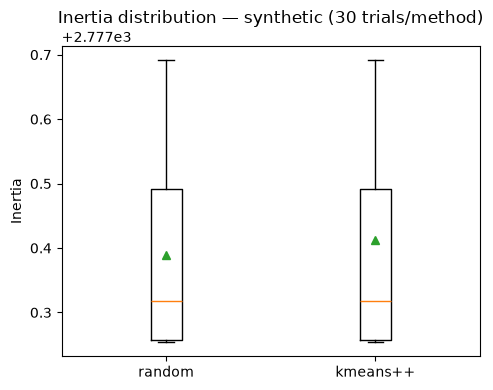

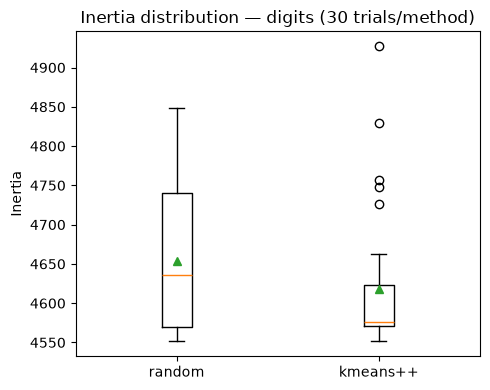

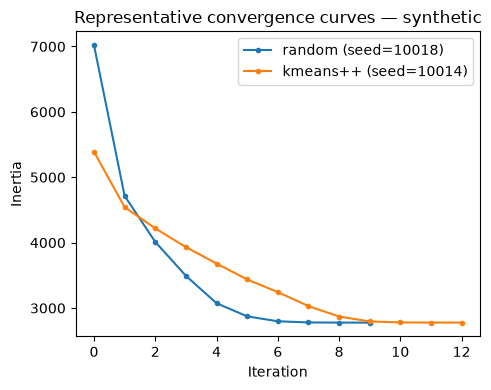

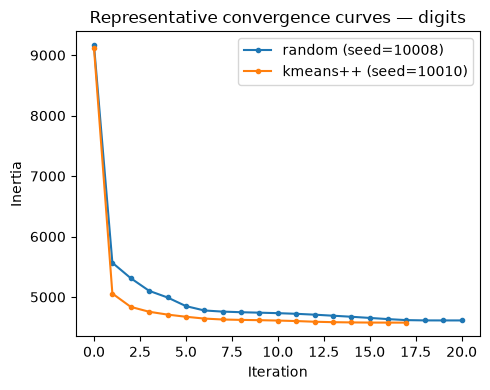

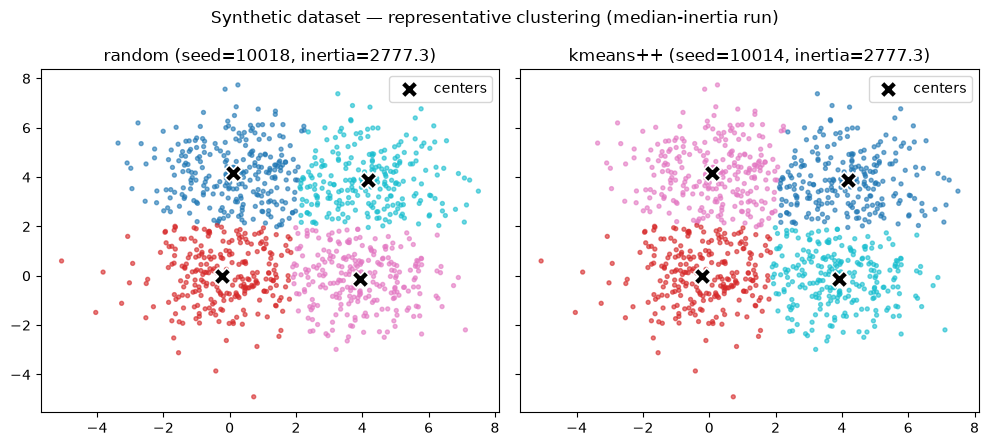

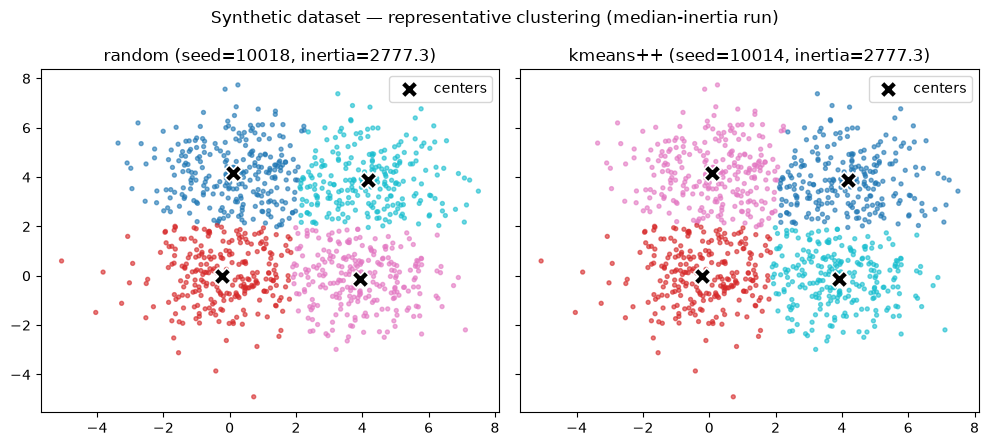

In [15]:
import matplotlib.pyplot as plt


def plot_inertia_distribution(df, dataset_name, save_path):
    subset = df[df.dataset == dataset_name]
    methods = list(subset["method"].unique())
    data = [subset[subset.method == m]["inertia"].values for m in methods]

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.boxplot(data, tick_labels=methods, showmeans=True)
    ax.set_ylabel("Inertia")
    n_trials = len(subset) // len(methods)
    ax.set_title(f"Inertia distribution — {dataset_name} ({n_trials} trials/method)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    return fig


def plot_convergence_curves(df, full_results, dataset_name, methods, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    for method in methods:
        result, seed = select_representative_run(df, full_results, dataset_name, method)
        history = result["inertia_history"]
        ax.plot(range(len(history)), history, marker="o", markersize=3, label=f"{method} (seed={seed})")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Inertia")
    ax.set_title(f"Representative convergence curves — {dataset_name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    return fig


def plot_synthetic_clusters(df, X, full_results, methods, save_path):
    fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4.5), sharex=True, sharey=True)
    if len(methods) == 1:
        axes = [axes]
    for ax, method in zip(axes, methods):
        result, seed = select_representative_run(df, full_results, "synthetic", method)
        labels, centers = result["labels"], result["centers"]
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=8, alpha=0.6)
        ax.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=150,
                   edgecolor="white", linewidth=1.2, label="centers")
        ax.set_title(f"{method} (seed={seed}, inertia={result['inertia']:.1f})")
        ax.legend()
    fig.suptitle("Synthetic dataset — representative clustering (median-inertia run)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    return fig


for dataset_name in results_df["dataset"].unique():
    plot_inertia_distribution(results_df, dataset_name,
                               f"outputs/figures/inertia_distribution_{dataset_name}.png")

for dataset_name in results_df["dataset"].unique():
    plot_convergence_curves(results_df, all_full_results, dataset_name, METHODS,
                             f"outputs/figures/convergence_{dataset_name}.png")

plot_synthetic_clusters(results_df, X_synth, all_full_results, METHODS,
                         "outputs/figures/synthetic_clusters.png")